# PCB defect benchmark + interactive viewer

Loads the cached patch classifier from `pipeline_cache/patch_classifier.pt` and:

1. Runs the full pipeline (register → propose → classify) on every validation sample, reports per-class precision/recall/F1 at the detection level, plus latency.
2. Provides an interactive viewer: pick a layout, flaw type, and specific image to see ground-truth boxes (red) vs detections (lime).

In [1]:
import time
from collections import Counter, defaultdict
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
from matplotlib.patches import Rectangle
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

import pcb_lib as L

print('device:', L.DEVICE)
model = L.load_trained_model()
print(f'model loaded ({sum(p.numel() for p in model.parameters())/1e6:.1f}M params)')

ALL = L.build_index()
VAL_LAYOUTS = {'10', '11', '12'}
VAL = [s for s in ALL if s.layout in VAL_LAYOUTS]
print(f'val samples: {len(VAL)} across layouts {sorted(VAL_LAYOUTS)}')

device: mps
model loaded (11.2M params)
val samples: 152 across layouts ['10', '11', '12']


## 1. Benchmark on val layouts

Each GT box is **matched** if any non-`none` detection with the same class has IoU > 0.1 with it. False positives are detections that don't match any GT box.

In [2]:
SCORE_THRESH = 0.5
IOU_MATCH = 0.1

gt_count = Counter()           # per class
tp_count = Counter()           # per class
det_count = Counter()          # per class (all detections, including FPs)
fp_count = Counter()           # per class
stage_a_recall_hits = Counter()
stage_a_recall_total = Counter()
total_props = 0
ok_samples = 0
latencies = []
per_sample = []                # for the viewer / drilldown

for s in tqdm(VAL, desc='val'):
    t0 = time.time()
    warped, clean, dets, H, ok = L.detect(model, s.img_path, s.clean_path, score_thresh=SCORE_THRESH)
    latencies.append(time.time() - t0)
    if not ok:
        continue
    ok_samples += 1

    gt_boxes = L.warp_boxes(s.boxes, H)
    # Stage A bookkeeping (cheap second pass — we still have warped/clean)
    props = L.propose(warped, clean)
    total_props += len(props)
    for label, x0, y0, x1, y1 in gt_boxes:
        stage_a_recall_total[label.lower()] += 1
        if any(L.iou((x0, y0, x1, y1), p) > IOU_MATCH for p in props):
            stage_a_recall_hits[label.lower()] += 1

    # Detection-level scoring
    matched_gt = [False] * len(gt_boxes)
    for box, pred_label, score in dets:
        det_count[pred_label] += 1
        hit = False
        for i, (gt_label, gx0, gy0, gx1, gy1) in enumerate(gt_boxes):
            if matched_gt[i]: continue
            if pred_label != gt_label.lower(): continue
            if L.iou(box, (gx0, gy0, gx1, gy1)) > IOU_MATCH:
                matched_gt[i] = True; hit = True; break
        if hit:
            tp_count[pred_label] += 1
        else:
            fp_count[pred_label] += 1
    for (gt_label, _, _, _, _), m in zip(gt_boxes, matched_gt):
        gt_count[gt_label.lower()] += 1

    per_sample.append({
        'sample': s, 'warped': warped, 'clean': clean,
        'gt': gt_boxes, 'dets': dets, 'props': props, 'H': H,
    })

print(f'\nregistered: {ok_samples}/{len(VAL)}')
print(f'mean latency: {1000*np.mean(latencies):.0f} ms/image  (p95: {1000*np.percentile(latencies, 95):.0f} ms)')
print(f'proposals/image: {total_props/max(ok_samples,1):.1f}')

val:   0%|          | 0/152 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
defect_classes = [c for c in L.CLASSES if c != 'none']
rows = []
for c in defect_classes:
    n_gt = gt_count.get(c, 0)
    tp = tp_count.get(c, 0)
    fp = fp_count.get(c, 0)
    recall = tp / n_gt if n_gt else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    sa = stage_a_recall_hits.get(c, 0)
    sa_total = stage_a_recall_total.get(c, 0)
    sa_rec = sa / sa_total if sa_total else 0.0
    rows.append((c, n_gt, tp, fp, precision, recall, f1, sa_rec))

print(f'{"class":<18}{"n_gt":>6}{"TP":>6}{"FP":>6}{"prec":>8}{"rec":>8}{"F1":>8}{"stageA_rec":>14}')
for c, n, tp, fp, p, r, f, sa in rows:
    print(f'{c:<18}{n:>6}{tp:>6}{fp:>6}{p:>8.2f}{r:>8.2f}{f:>8.2f}{sa:>14.2f}')
tot_gt = sum(r[1] for r in rows)
tot_tp = sum(r[2] for r in rows)
tot_fp = sum(r[3] for r in rows)
macro_p = np.mean([r[4] for r in rows])
macro_r = np.mean([r[5] for r in rows])
macro_f = np.mean([r[6] for r in rows])
print('-' * 76)
print(f'{"micro":<18}{tot_gt:>6}{tot_tp:>6}{tot_fp:>6}'
      f'{tot_tp/(tot_tp+tot_fp):>8.2f}{tot_tp/tot_gt:>8.2f}'
      f'{2*tot_tp/(2*tot_tp+tot_fp+(tot_gt-tot_tp)):>8.2f}')
print(f'{"macro":<18}{"":>6}{"":>6}{"":>6}{macro_p:>8.2f}{macro_r:>8.2f}{macro_f:>8.2f}')

class               n_gt    TP    FP    prec     rec      F1    stageA_rec
missing_hole         127   127     0    1.00    1.00    1.00          1.00
mouse_bite           126   126     1    0.99    1.00    1.00          1.00
open_circuit         131   126     4    0.97    0.96    0.97          0.96
short                126   121     1    0.99    0.96    0.98          0.99
spur                 126   126    10    0.93    1.00    0.96          1.00
spurious_copper      132   132     2    0.99    1.00    0.99          1.00
----------------------------------------------------------------------------
micro                768   758    18    0.98    0.99    0.98
macro                                   0.98    0.99    0.98


total FPs: 14   FP rate (FP / all detections): 1.80%
  FP[missing_hole      ] = 0
  FP[mouse_bite        ] = 1
  FP[open_circuit      ] = 4
  FP[short             ] = 1
  FP[spur              ] = 6
  FP[spurious_copper   ] = 2


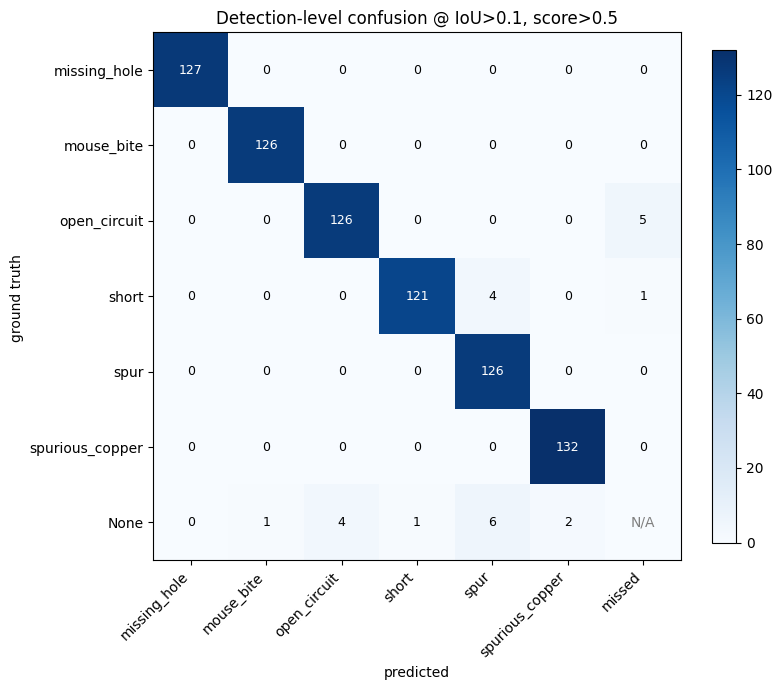

In [ ]:
# Detection-level confusion: GT class vs predicted class for matched detections,
# plus a rightmost 'missed' column (FN per GT class) and a bottom 'FP (no GT)' row
# (FP attributed to predicted class). Bottom-right cell is meaningless (no GT, no detection).
col_labels = defect_classes + ['missed']
row_labels = defect_classes + ['None']
cm = np.zeros((len(row_labels), len(col_labels)), dtype=int)
for rec in per_sample:
    matched = [False] * len(rec['gt'])
    for box, pred_label, score in rec['dets']:
        # find a matching GT to attribute the prediction
        best_iou = 0; best_i = -1
        for i, (gl, gx0, gy0, gx1, gy1) in enumerate(rec['gt']):
            if matched[i]: continue
            ov = L.iou(box, (gx0, gy0, gx1, gy1))
            if ov > best_iou: best_iou, best_i = ov, i
        if best_i >= 0 and best_iou > IOU_MATCH:
            matched[best_i] = True
            gt_idx = defect_classes.index(rec['gt'][best_i][0].lower())
            pred_idx = defect_classes.index(pred_label)
            cm[gt_idx, pred_idx] += 1
        else:
            # no GT claimed this detection → false positive, attributed by predicted class
            pred_idx = defect_classes.index(pred_label)
            cm[-1, pred_idx] += 1
    for (gl, _, _, _, _), m in zip(rec['gt'], matched):
        if not m:
            cm[defect_classes.index(gl.lower()), -1] += 1

# Per-class FP totals (bottom row) and overall FP rate
fp_per_class = cm[-1, :len(defect_classes)]
total_fp = int(fp_per_class.sum())
total_dets = int(cm[:, :len(defect_classes)].sum())  # all detections (TP + FP)
print(f'total FPs: {total_fp}   FP rate (FP / all detections): {total_fp / max(total_dets, 1):.2%}')
for c, n in zip(defect_classes, fp_per_class):
    print(f'  FP[{c:<18}] = {int(n)}')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(col_labels))); ax.set_yticks(range(len(row_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha='right')
ax.set_yticklabels(row_labels)
ax.set_xlabel('predicted')
ax.set_ylabel('ground truth ')
ax.set_title(f'Detection-level confusion @ IoU>{IOU_MATCH}, score>{SCORE_THRESH}')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # bottom-right cell (FP row × missed col) is meaningless
        if i == cm.shape[0] - 1 and j == cm.shape[1] - 1:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=10, color='grey')
            continue
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=9,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
# Separator lines for the extra row/col
# ax.axhline(len(defect_classes) - 0.5, color='black', lw=0.6)
# ax.axvline(len(defect_classes) - 0.5, color='black', lw=0.6)
fig.colorbar(im, ax=ax, fraction=0.04); plt.tight_layout(); plt.show()

## 2. Interactive viewer

Filter by layout / flaw type, pick a specific image, adjust the score threshold. The plot updates on every change.

- **Red** = ground-truth box  
- **Lime** = detection (class + confidence)  
- **Cyan (thin)** = Stage-A proposal that the classifier rejected (`none` or below threshold)

In [ ]:
# Use whichever samples we have results for (so the viewer reuses cached pipeline outputs when possible).
INDEX_BY_KEY = {(r['sample'].layout, r['sample'].flaw_type, r['sample'].img_path.name): r for r in per_sample}
VIEWER_POOL = ALL  # let user pick any sample, not just val

layouts_avail = sorted({s.layout for s in VIEWER_POOL})
flaws_avail = sorted({s.flaw_type for s in VIEWER_POOL})

layout_dd = widgets.Dropdown(options=['(any)'] + layouts_avail, value='10', description='Layout:')
flaw_dd = widgets.Dropdown(options=['(any)'] + flaws_avail, value='(any)', description='Flaw:')
image_dd = widgets.Dropdown(options=[], description='Image:', layout=widgets.Layout(width='480px'))
score_sl = widgets.FloatSlider(value=0.5, min=0.0, max=0.99, step=0.01, description='Score≥', readout_format='.2f')
rand_btn = widgets.Button(description='Random', button_style='info')
show_props = widgets.Checkbox(value=True, description='show rejected proposals')
out = widgets.Output()


def _matching_samples():
    pool = VIEWER_POOL
    if layout_dd.value != '(any)':
        pool = [s for s in pool if s.layout == layout_dd.value]
    if flaw_dd.value != '(any)':
        pool = [s for s in pool if s.flaw_type == flaw_dd.value]
    return pool


def _refresh_image_options(*_):
    pool = _matching_samples()
    image_dd.options = [(s.img_path.name, s) for s in pool]
    if image_dd.options:
        image_dd.value = image_dd.options[0][1]


def _render(*_):
    out.clear_output(wait=True)
    s = image_dd.value
    if s is None:
        with out: print('no matching images'); return
    key = (s.layout, s.flaw_type, s.img_path.name)
    cached = INDEX_BY_KEY.get(key)
    if cached is not None:
        warped, clean, H = cached['warped'], cached['clean'], cached['H']
        gt = cached['gt']; props = cached['props']
        # re-score with current threshold from the cached classifier outputs would need re-running detect;
        # cheaper to just call detect() again with the chosen threshold.
    _, _, dets, H, ok = L.detect(model, s.img_path, s.clean_path, score_thresh=score_sl.value)
    if cached is None:
        # not in val cache — compute fresh
        warped = L.imread_color(s.img_path)
        clean = L.imread_color(s.clean_path)
        warped, H, ok = L.register(warped, clean)
        gt = L.warp_boxes(s.boxes, H) if ok else s.boxes
        props = L.propose(warped, clean) if ok else []

    det_boxes = {tuple(d[0]) for d in dets}
    matched_gt = [False] * len(gt)
    for box, pred_label, _ in dets:
        for i, (gl, gx0, gy0, gx1, gy1) in enumerate(gt):
            if matched_gt[i]: continue
            if L.iou(box, (gx0, gy0, gx1, gy1)) > IOU_MATCH and pred_label == gl.lower():
                matched_gt[i] = True; break
    tp = sum(matched_gt)
    n_gt = len(gt); n_dets = len(dets); n_fp = n_dets - tp

    with out:
        fig, ax = plt.subplots(figsize=(13, 8))
        ax.imshow(warped); ax.axis('off')
        ax.set_title(f'{s.flaw_type} · {s.img_path.name}   |   GT={n_gt}  TP={tp}  FP={n_fp}  proposals={len(props)}')
        if show_props.value:
            for x0, y0, x1, y1 in props:
                if (x0, y0, x1, y1) in det_boxes: continue
                ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, lw=0.8, ec='cyan', fc='none'))
        for label, x0, y0, x1, y1 in gt:
            ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, lw=2.5, ec='red', fc='none'))
        for (x0, y0, x1, y1), label, score in dets:
            ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, lw=2, ec='lime', fc='none'))
            ax.text(x0, max(y0-4, 0), f'{label} {score:.2f}', color='black', fontsize=8,
                    bbox=dict(facecolor='lime', edgecolor='none', pad=1))
        plt.tight_layout(); plt.show()


def _on_random(_):
    pool = _matching_samples()
    if not pool: return
    image_dd.value = np.random.choice([s for s in pool])


layout_dd.observe(_refresh_image_options, names='value')
flaw_dd.observe(_refresh_image_options, names='value')
image_dd.observe(_render, names='value')
score_sl.observe(_render, names='value')
show_props.observe(_render, names='value')
rand_btn.on_click(_on_random)

_refresh_image_options()
controls = widgets.VBox([
    widgets.HBox([layout_dd, flaw_dd, rand_btn]),
    widgets.HBox([image_dd, score_sl, show_props]),
])
display(controls, out)
_render()

Output()

### Reading the viewer

- Drop the **Score≥** slider to surface low-confidence detections — useful for finding where the classifier is unsure.
- Turn off **show rejected proposals** for a cleaner picture; turn it on to debug Stage A vs Stage B contributions.
- Pick a layout outside the val set (01, 04–09) to spot any layout-specific overfitting.